<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/09_SEAID_Early_Warning_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEAID Temporal Early-Warning Framework

## Purpose

This notebook operationalizes the predictive modeling results developed in the earlier SEAID notebooks.

The framework uses the selected XGBoost models to generate student-level risk probabilities at four course checkpoints:

- Day 7
- Day 14
- Day 21
- Day 30

The primary goals are to:

1. Generate a probability of unsuccessful course completion for each student.
2. Assign students to interpretable risk tiers.
3. Identify students whose risk persists or increases over time.
4. Produce checkpoint-specific intervention lists.
5. Support timely, proportionate, and human-centered student outreach.

The predictions produced by this framework are intended to support professional judgment rather than replace it.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

PROCESSED_DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

NOTEBOOK_DIR = (
    PROJECT_DIR
    / "notebooks"
)

MODEL_DIR = (
    PROJECT_DIR
    / "models"
)

OUTPUTS_DIR = (
    PROJECT_DIR
    / "outputs"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "figures"
)

print("Project exists:", PROJECT_DIR.exists())
print("Model directory exists:", MODEL_DIR.exists())
print("Processed data directory exists:", PROCESSED_DATA_DIR.exists())

Project exists: True
Model directory exists: True
Processed data directory exists: True


In [3]:
import joblib
import pandas as pd
import numpy as np

In [4]:
DAY7_MODEL = MODEL_DIR / "xgboost_day7.joblib"
DAY14_MODEL = MODEL_DIR / "xgboost_day14.joblib"
DAY21_MODEL = MODEL_DIR / "xgboost_day21.joblib"
DAY30_MODEL = MODEL_DIR / "xgboost_day30.joblib"

print(DAY7_MODEL.exists())
print(DAY14_MODEL.exists())
print(DAY21_MODEL.exists())
print(DAY30_MODEL.exists())

True
True
True
True


In [5]:
xgb_day7 = joblib.load(DAY7_MODEL)
xgb_day14 = joblib.load(DAY14_MODEL)
xgb_day21 = joblib.load(DAY21_MODEL)
xgb_day30 = joblib.load(DAY30_MODEL)

print("All models loaded successfully.")

All models loaded successfully.


In [6]:
day7_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day7_dataset.csv"
)

day14_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day14_dataset.csv"
)

day21_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day21_dataset.csv"
)

day30_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day30_dataset.csv"
)

In [7]:
print(day7_df.shape)
print(day14_df.shape)
print(day21_df.shape)
print(day30_df.shape)

(32593, 82)
(32593, 82)
(32593, 82)
(32593, 82)


In [8]:
TARGET = "target_success"

print(day7_df[TARGET].value_counts())

target_success
0    17208
1    15385
Name: count, dtype: int64


In [9]:
def inspect_model_features(model, model_name):
    print(f"\n{model_name}")

    if hasattr(model, "feature_names_in_"):
        print(
            "Expected features:",
            len(model.feature_names_in_)
        )

        print(
            list(model.feature_names_in_)[:10]
        )
    else:
        print(
            "No feature_names_in_ attribute found."
        )


inspect_model_features(
    xgb_day7,
    "Day 7 XGBoost"
)

inspect_model_features(
    xgb_day14,
    "Day 14 XGBoost"
)

inspect_model_features(
    xgb_day21,
    "Day 21 XGBoost"
)

inspect_model_features(
    xgb_day30,
    "Day 30 XGBoost"
)


Day 7 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 14 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 21 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']

Day 30 XGBoost
Expected features: 74
['code_module', 'code_presentation', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record']


In [10]:
print(day7_df.columns.tolist())

['code_module', 'code_presentation', 'id_student', 'gender', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target_success', 'total_clicks', 'average_clicks_per_record', 'median_clicks_per_record', 'maximum_clicks_in_record', 'vle_records', 'active_days', 'unique_vle_activities', 'first_activity_day', 'last_activity_day', 'clicks_per_active_day', 'activity_span_days', 'clicks_per_vle_activity', 'log_total_clicks', 'assessments_completed', 'average_score', 'median_score', 'minimum_score', 'maximum_score', 'score_std', 'average_weight', 'total_weight_completed', 'first_submission_day', 'last_submission_day', 'banked_assessments', 'assessment_span_days', 'score_range', 'weighted_average_score', 'score_improvement', 'assessment_intensity', 'log_assessments_completed', 'date_registration', 'date_unregistration', 'registered_before_start', 'registered_after_start', 'days_registered_before_start', 'withdrew', 'days_until_withdrawal', 'early_withdrawal', 'region_East

In [11]:
TARGET = "target_success"

POSSIBLE_ID_COLUMNS = [
    "id_student",
    "code_module",
    "code_presentation"
]

In [12]:
def prepare_model_features(
    dataframe,
    model,
    target_column="target_success"
):
    if hasattr(model, "feature_names_in_"):

        expected_features = list(
            model.feature_names_in_
        )

        missing_features = [
            column
            for column in expected_features
            if column not in dataframe.columns
        ]

        if missing_features:
            raise ValueError(
                "Missing required features: "
                f"{missing_features}"
            )

        X = dataframe[
            expected_features
        ].copy()

    else:
        excluded_columns = [
            target_column
        ]

        X = dataframe.drop(
            columns=[
                column
                for column in excluded_columns
                if column in dataframe.columns
            ]
        ).copy()

    return X

In [13]:
X_day7 = prepare_model_features(
    day7_df,
    xgb_day7
)

X_day14 = prepare_model_features(
    day14_df,
    xgb_day14
)

X_day21 = prepare_model_features(
    day21_df,
    xgb_day21
)

X_day30 = prepare_model_features(
    day30_df,
    xgb_day30
)

In [14]:
print("Day 7:", X_day7.shape)
print("Day 14:", X_day14.shape)
print("Day 21:", X_day21.shape)
print("Day 30:", X_day30.shape)

Day 7: (32593, 74)
Day 14: (32593, 74)
Day 21: (32593, 74)
Day 30: (32593, 74)


In [15]:
print("Day 7 classes:", xgb_day7.classes_)
print("Day 14 classes:", xgb_day14.classes_)
print("Day 21 classes:", xgb_day21.classes_)
print("Day 30 classes:", xgb_day30.classes_)

Day 7 classes: [0 1]
Day 14 classes: [0 1]
Day 21 classes: [0 1]
Day 30 classes: [0 1]


In [16]:
day7_risk_probability = (
    xgb_day7.predict_proba(X_day7)[:, 0]
)

day14_risk_probability = (
    xgb_day14.predict_proba(X_day14)[:, 0]
)

day21_risk_probability = (
    xgb_day21.predict_proba(X_day21)[:, 0]
)

day30_risk_probability = (
    xgb_day30.predict_proba(X_day30)[:, 0]
)

In [17]:
print(
    "Day 7 risk range:",
    day7_risk_probability.min(),
    day7_risk_probability.max()
)

print(
    "Day 14 risk range:",
    day14_risk_probability.min(),
    day14_risk_probability.max()
)

print(
    "Day 21 risk range:",
    day21_risk_probability.min(),
    day21_risk_probability.max()
)

print(
    "Day 30 risk range:",
    day30_risk_probability.min(),
    day30_risk_probability.max()
)

Day 7 risk range: 0.02985096 0.99066323
Day 14 risk range: 0.03072071 0.995707
Day 21 risk range: 0.016376913 0.99761635
Day 30 risk range: 0.012935638 0.9989565


In [18]:
def assign_risk_tier(probability):

    if probability >= 0.75:
        return "Critical"

    elif probability >= 0.50:
        return "High"

    elif probability >= 0.25:
        return "Moderate"

    else:
        return "Low"

In [19]:
def build_prediction_table(
    dataframe,
    risk_probability,
    checkpoint
):

    prediction_df = pd.DataFrame()

    for column in [
        "id_student",
        "code_module",
        "code_presentation"
    ]:

        if column in dataframe.columns:
            prediction_df[column] = dataframe[column]

    prediction_df["Checkpoint"] = checkpoint

    prediction_df["Risk Probability"] = risk_probability

    prediction_df["Risk Tier"] = (
        prediction_df["Risk Probability"]
        .apply(assign_risk_tier)
    )

    prediction_df["Predicted Outcome"] = np.where(
        prediction_df["Risk Probability"] >= 0.50,
        "At Risk",
        "Likely Successful"
    )

    if TARGET in dataframe.columns:
        prediction_df["Actual Outcome"] = np.where(
            dataframe[TARGET] == 1,
            "Successful",
            "Unsuccessful"
        )

    return prediction_df

In [20]:
predictions_day7 = build_prediction_table(
    day7_df,
    day7_risk_probability,
    7
)

predictions_day14 = build_prediction_table(
    day14_df,
    day14_risk_probability,
    14
)

predictions_day21 = build_prediction_table(
    day21_df,
    day21_risk_probability,
    21
)

predictions_day30 = build_prediction_table(
    day30_df,
    day30_risk_probability,
    30
)

In [21]:
display(predictions_day7.head())

print("\nRisk Tier Counts\n")

print(
    predictions_day7["Risk Tier"]
    .value_counts()
)

,id_student,code_module,code_presentation,Checkpoint,Risk Probability,Risk Tier,Predicted Outcome,Actual Outcome
0,11391,AAA,2013J,7,0.437626,Moderate,Likely Successful,Successful
1,28400,AAA,2013J,7,0.178204,Low,Likely Successful,Successful
2,30268,AAA,2013J,7,0.254898,Moderate,Likely Successful,Unsuccessful
3,31604,AAA,2013J,7,0.174247,Low,Likely Successful,Successful
4,32885,AAA,2013J,7,0.205438,Low,Likely Successful,Successful



Risk Tier Counts

Risk Tier
Moderate    11290
High         8773
Critical     7623
Low          4907
Name: count, dtype: int64


In [22]:
all_predictions = pd.concat(
    [
        predictions_day7,
        predictions_day14,
        predictions_day21,
        predictions_day30
    ],
    ignore_index=True
)

print(all_predictions.shape)

display(all_predictions.head())

(130372, 8)


,id_student,code_module,code_presentation,Checkpoint,Risk Probability,Risk Tier,Predicted Outcome,Actual Outcome
0,11391,AAA,2013J,7,0.437626,Moderate,Likely Successful,Successful
1,28400,AAA,2013J,7,0.178204,Low,Likely Successful,Successful
2,30268,AAA,2013J,7,0.254898,Moderate,Likely Successful,Unsuccessful
3,31604,AAA,2013J,7,0.174247,Low,Likely Successful,Successful
4,32885,AAA,2013J,7,0.205438,Low,Likely Successful,Successful


In [23]:
PREDICTION_FILE = (
    RESULTS_DIR /
    "student_risk_predictions.csv"
)

all_predictions.to_csv(
    PREDICTION_FILE,
    index=False
)

print("Saved:", PREDICTION_FILE)

Saved: /content/drive/MyDrive/SEAID_Framework/results/student_risk_predictions.csv


In [24]:
risk_tracker = (
    all_predictions
    .pivot_table(
        index=[
            "id_student",
            "code_module",
            "code_presentation"
        ],
        columns="Checkpoint",
        values="Risk Probability"
    )
    .reset_index()
)

risk_tracker.columns = [
    "id_student",
    "code_module",
    "code_presentation",
    "Day7",
    "Day14",
    "Day21",
    "Day30"
]

display(risk_tracker.head())

,id_student,code_module,code_presentation,Day7,Day14,Day21,Day30
0,3733,DDD,2013J,0.809787,0.926536,0.971373,0.991904
1,6516,AAA,2014J,0.112310,0.077815,0.148093,0.082690
2,8462,DDD,2013J,0.372089,0.299075,0.350706,0.283485
3,8462,DDD,2014J,0.762183,0.759273,0.780417,0.715943
4,11391,AAA,2013J,0.437626,0.429615,0.238579,0.241975


In [25]:
risk_tracker["Change_7_to_30"] = (
    risk_tracker["Day30"]
    - risk_tracker["Day7"]
)

risk_tracker["Maximum_Risk"] = (
    risk_tracker[
        [
            "Day7",
            "Day14",
            "Day21",
            "Day30"
        ]
    ]
    .max(axis=1)
)

risk_tracker["Average_Risk"] = (
    risk_tracker[
        [
            "Day7",
            "Day14",
            "Day21",
            "Day30"
        ]
    ]
    .mean(axis=1)
)

In [26]:
def classify_trend(row):

    if row["Day30"] >= 0.75:
        return "Persistently Critical"

    elif row["Change_7_to_30"] >= 0.20:
        return "Increasing Risk"

    elif row["Change_7_to_30"] <= -0.20:
        return "Improving"

    else:
        return "Stable"


risk_tracker["Risk Trend"] = (
    risk_tracker.apply(
        classify_trend,
        axis=1
    )
)

In [27]:
print(
    risk_tracker["Risk Trend"]
    .value_counts()
)

display(risk_tracker.head())

Risk Trend
Stable                   18080
Persistently Critical     9640
Improving                 3902
Increasing Risk            971
Name: count, dtype: int64


,id_student,code_module,code_presentation,Day7,Day14,Day21,Day30,Change_7_to_30,Maximum_Risk,Average_Risk,Risk Trend
0,3733,DDD,2013J,0.809787,0.926536,0.971373,0.991904,0.182117,0.991904,0.924900,Persistently Critical
1,6516,AAA,2014J,0.112310,0.077815,0.148093,0.082690,-0.029621,0.148093,0.105227,Stable
2,8462,DDD,2013J,0.372089,0.299075,0.350706,0.283485,-0.088603,0.372089,0.326339,Stable
3,8462,DDD,2014J,0.762183,0.759273,0.780417,0.715943,-0.046240,0.780417,0.754454,Stable
4,11391,AAA,2013J,0.437626,0.429615,0.238579,0.241975,-0.195650,0.437626,0.336949,Stable


In [28]:
def intervention_level(row):

    if row["Day30"] >= 0.90:
        return "Immediate Intervention"

    elif row["Day30"] >= 0.75:
        return "Advisor Outreach"

    elif row["Average_Risk"] >= 0.50:
        return "Faculty Check-In"

    elif row["Average_Risk"] >= 0.25:
        return "Continue Monitoring"

    else:
        return "No Action Needed"


risk_tracker["Recommended Action"] = (
    risk_tracker.apply(
        intervention_level,
        axis=1
    )
)

In [29]:
print(
    risk_tracker["Recommended Action"]
    .value_counts()
)

Recommended Action
Continue Monitoring       10827
Immediate Intervention     6948
Faculty Check-In           6440
No Action Needed           5686
Advisor Outreach           2692
Name: count, dtype: int64


In [30]:
dashboard = (
    risk_tracker
    .groupby("Recommended Action")
    .agg(
        Students=("id_student", "count"),
        Mean_Risk=("Average_Risk", "mean"),
        Mean_Day30_Risk=("Day30", "mean")
    )
    .sort_values(
        "Mean_Day30_Risk",
        ascending=False
    )
)

display(dashboard)

,Students,Mean_Risk,Mean_Day30_Risk
Recommended Action,,,
Immediate Intervention,6948,0.898381,0.978220
Advisor Outreach,2692,0.739413,0.824225
Faculty Check-In,6440,0.615812,0.570730
Continue Monitoring,10827,0.367710,0.337438
No Action Needed,5686,0.179357,0.150575


In [31]:
risk_tracker.to_csv(
    RESULTS_DIR /
    "student_risk_tracker.csv",
    index=False
)

dashboard.to_csv(
    RESULTS_DIR /
    "intervention_dashboard.csv",
    index=False
)

print("Framework outputs saved.")

Framework outputs saved.


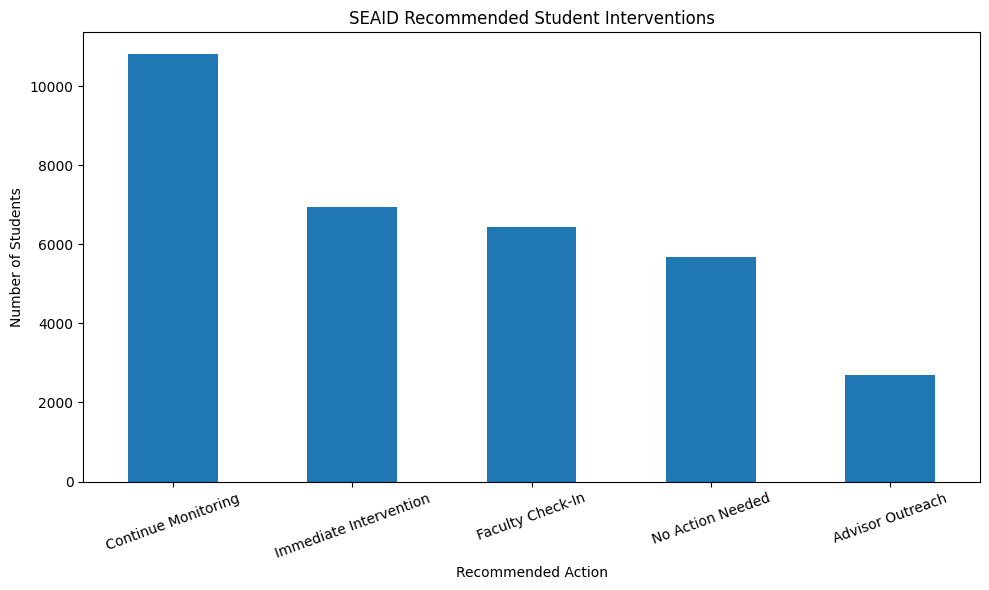

In [32]:
import matplotlib.pyplot as plt

action_counts = (
    risk_tracker["Recommended Action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

action_counts.plot(kind="bar")

plt.title("SEAID Recommended Student Interventions")

plt.xlabel("Recommended Action")

plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "recommended_interventions.png",
    dpi=300
)

plt.show()